<a href="https://colab.research.google.com/github/jjuliiann/mly1101-machine-learning-portafolio/blob/main/actividad_practica18_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ACTIVIDAD**

In [16]:
import pandas as pd
import numpy as np
# Generación del Dataset Transaccional para la Actividad Práctica
np.random.seed(42)
n_clientes = 80
data_practica = {
'CustomerId': range(10001, 10001 + n_clientes),
'Surname': [f'Cliente_{i}' for i in range(n_clientes)],
'Age': np.random.choice([25, 34, 45, np.nan, 52, 28, np.nan, 39],
size=n_clientes),
'Balance': np.random.randint(5000, 85000, size=n_clientes).astype(float),
'EstimatedSalary': np.random.randint(45000, 95000, size=n_clientes)
}
df_taller = pd.DataFrame(data_practica)
# Inyección de anomalías para auditoría
df_taller.loc[12, 'Balance'] = 4500000.0
df_taller.loc[25, 'Balance'] = 5200000.0
# Forzar correlación lineal artificial entre salario y saldo
df_taller['EstimatedSalary'] = df_taller['Balance'] * 0.15 + np.random.normal(0,
2000, n_clientes)
print("=== DATASET INSTANCIADO CON ÉXITO ===")
print(f"Registros totales para analizar: {df_taller.shape[0]}")

=== DATASET INSTANCIADO CON ÉXITO ===
Registros totales para analizar: 80


In [17]:
# 2. código de diagnóstico y limpieza
# Detectar nulos por columna
print("1. Conteo de valores nulos por columna:")
print(df_taller.isnull().sum())
print("\n")
# Contar el total de registros completamente duplicados

print(f"2. Total filas duplicadas detectadas:{df_taller.duplicated().sum()}")
print("\n")
# Eliminar duplicados manteniendo el primer registro y

df_taller.drop_duplicates(keep='first', inplace=True)
df_taller.reset_index(drop=True, inplace=True)
# Imputar valores con la mediana en la columna 'Age'
mediana = df_taller['Age'].median()
df_taller['Age'].fillna(mediana, inplace=True)
print("=== DATAFRAME PROCESADO Y LIMPIO ===")
print(df_taller)

1. Conteo de valores nulos por columna:
CustomerId          0
Surname             0
Age                26
Balance             0
EstimatedSalary     0
dtype: int64


2. Total filas duplicadas detectadas:0


=== DATAFRAME PROCESADO Y LIMPIO ===
    CustomerId     Surname   Age  Balance  EstimatedSalary
0        10001   Cliente_0  39.0  53555.0      9058.097465
1        10002   Cliente_1  39.0  22159.0      4410.827382
2        10003   Cliente_2  52.0  40920.0      6194.198927
3        10004   Cliente_3  39.0  72121.0      8423.975873
4        10005   Cliente_4  45.0  74479.0     12751.195610
..         ...         ...   ...      ...              ...
75       10076  Cliente_75  34.0  61044.0      8620.563296
76       10077  Cliente_76  39.0  72214.0     13024.759579
77       10078  Cliente_77  39.0  38827.0      5153.227952
78       10079  Cliente_78  39.0  60820.0     10393.225102
79       10080  Cliente_79  39.0  67623.0      7983.048260

[80 rows x 5 columns]


/tmp/ipykernel_5136/2336016683.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_taller['Age'].fillna(mediana, inplace=True)


In [18]:
# Cálculo de límites estadísticos
Q1 = df_taller['Balance'].quantile(0.25)
Q3 = df_taller['Balance'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
# Aplicación del filtro lógico de exclusión
df_limpio = df_taller[(df_taller['Balance'] >= limite_inferior) &
(df_taller['Balance'] <= limite_superior)]
df_limpio.head()

,CustomerId,Surname,Age,Balance,EstimatedSalary
0,10001,Cliente_0,39.0,53555.0,9058.097465
1,10002,Cliente_1,39.0,22159.0,4410.827382
2,10003,Cliente_2,52.0,40920.0,6194.198927
3,10004,Cliente_3,39.0,72121.0,8423.975873
4,10005,Cliente_4,45.0,74479.0,12751.195610


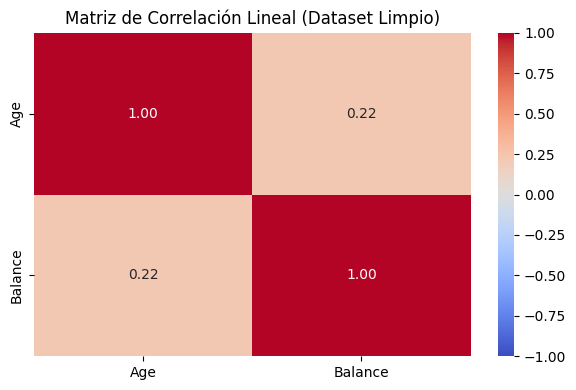

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Ajustamos la lista de columnas usando únicamente las variables numéricas existentes
columnas_validas = ['Age', 'Balance']
matriz_corr = df_limpio[columnas_validas].corr()
# 2. Configurar el lienzo de visualización
plt.figure(figsize=(6, 4))
# 3. Dibujar el mapa de calor (Heatmap) con Seaborn
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
# 4. Personalización del gráfico
plt.title("Matriz de Correlación Lineal (Dataset Limpio)")
plt.tight_layout()
plt.show()